# Problem #1 Use the titanic dataset and do the following preprocessing
i. Find size of data

ii. Display first five rows of the dataset

iii. Display data types of the columns

iv. Display Mathematical description of columns

v. Find missing values and then fill it

vi. Find duplicate rows and delete it

vii. Find correlation based on label

In [100]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [101]:
data = pd.read_csv("Titanic.csv")
print("Dataset Size (rows, columns):", data.shape)


Dataset Size (rows, columns): (891, 12)


In [102]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [103]:
data.dtypes


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [104]:
data.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [105]:
print("Before filling missing values:")
print(data.isnull().sum())

data['Age'].fillna(data['Age'].mean(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

print("\nAfter filling missing values:")
print(data.isnull().sum())


Before filling missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

After filling missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


/var/folders/7v/x365pgqd6_d1r94p70v20y380000gn/T/ipykernel_21602/200595424.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(), inplace=True)
/var/folders/7v/x365pgqd6_d1r94p70v20y380000gn/T/ipykernel_21602/200595424.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values al

In [106]:
print("Duplicate rows:", data.duplicated().sum())
data.drop_duplicates(inplace=True)


Duplicate rows: 0


In [107]:
corr = data.corr(numeric_only=True) # corrolation matrix
print(corr)

print('\n\nCorrelation with Survived:')

# or
data_num = data.drop(['PassengerId', 'Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], axis=1) # Numerical fields only
print(data_num.corr()['Survived'])


             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.033207 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.069809 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.331339  0.083081  0.018443   
Age             0.033207 -0.069809 -0.331339  1.000000 -0.232625 -0.179191   
SibSp          -0.057527 -0.035322  0.083081 -0.232625  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.179191  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.091566  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.091566  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


Correlation with Survived:
Survived    1.000000
Pclass     -0.338481
Age        -0.069809
SibSp      -0.035322
Parch       0.081629
Fare        0.257307
Name: Survived, dtype: float

# Problem #2 Perform Univariate EDA with titanic dataset
i. Perform Countplot() using categorical values 

ii. Using value_counts() print pie chart for categorical values

iii. Perform hist() for numerical columns

iv. Perform distplot() for numerical columns

v. Perform boxplot() for numerical columns

vi. Find skewness for the numerical columns

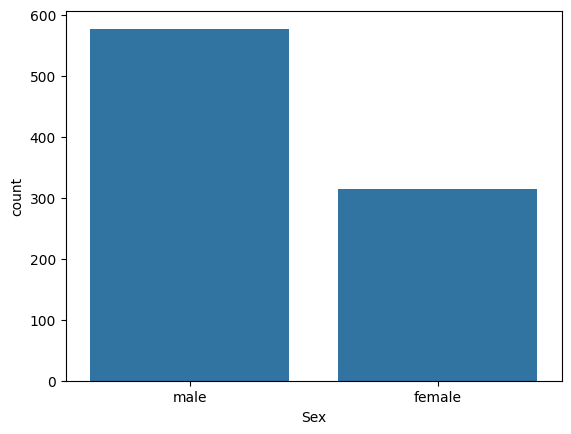

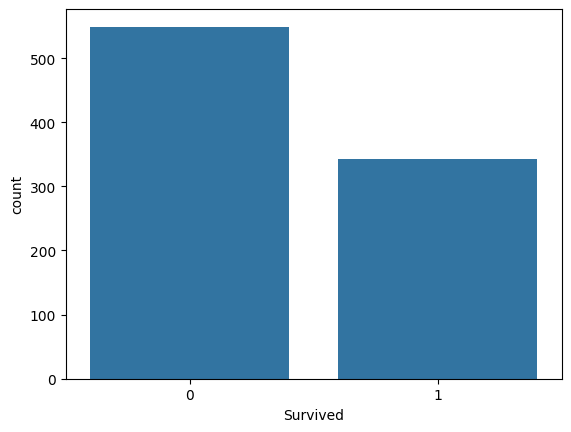

In [108]:
sns.countplot(x='Sex', data=data)
plt.show()

sns.countplot(x='Survived', data=data)
plt.show()


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


<Axes: ylabel='count'>

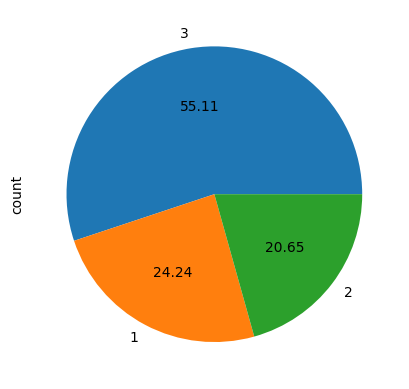

In [109]:
print(data.columns)
data['Pclass'].value_counts()

data['Pclass'].value_counts().plot(kind='pie', autopct='%0.2f')

array([[<Axes: title={'center': 'PassengerId'}>,
        <Axes: title={'center': 'Survived'}>,
        <Axes: title={'center': 'Pclass'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>,
        <Axes: title={'center': 'Parch'}>],
       [<Axes: title={'center': 'Fare'}>, <Axes: >, <Axes: >]],
      dtype=object)

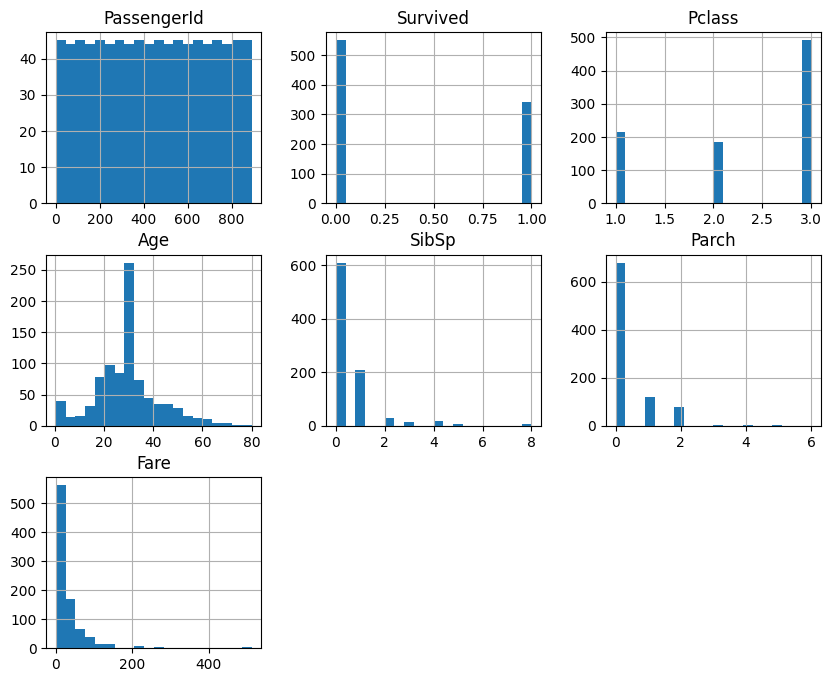

In [110]:
# plt.hist(data['Fare'], bins=30) 
data.hist(bins=20, figsize=(10,8)) 

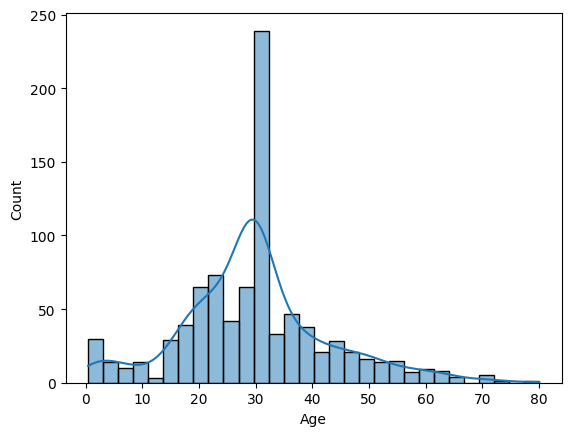

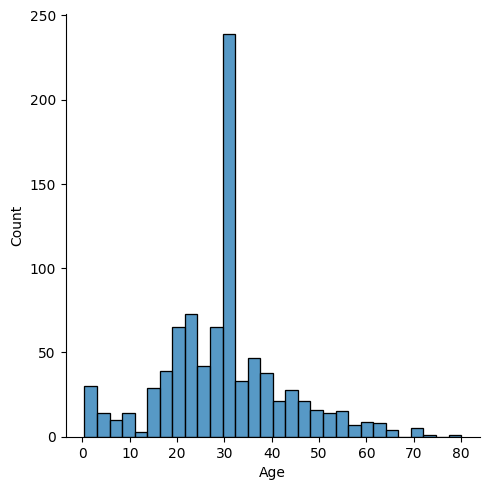

In [111]:
sns.histplot(data['Age'], kde=True)
sns.displot(data['Age'])
plt.show()


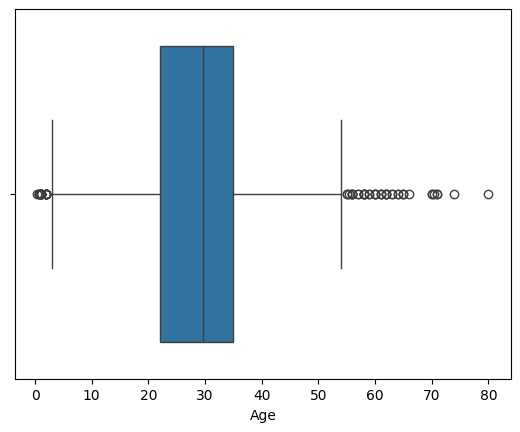

In [112]:
sns.boxplot(x=data['Age'])
plt.show()


In [113]:
print("Skewness:\n",data_num.skew())

Skewness:
 Survived    0.478523
Pclass     -0.630548
Age         0.434488
SibSp       3.695352
Parch       2.749117
Fare        4.787317
dtype: float64


# Problem #3 Perform Multivariate EDA with seaborn dataset
i. Perform scatterplot() for numerical vs numerical columns

ii. Perform scatterplot() for numerical vs categorical columns

iii. Perform scatterplot() for categorical vs categorical columns

In [114]:
df_iris = sns.load_dataset("iris")


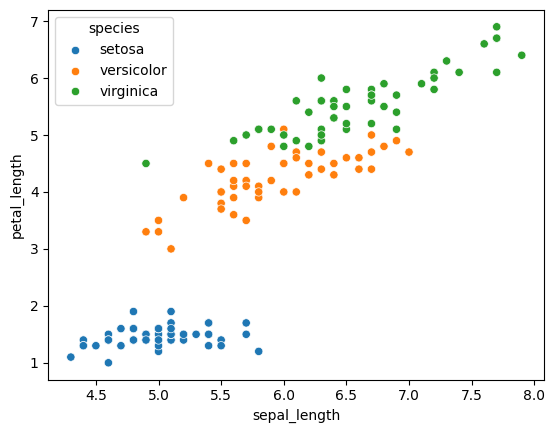

In [115]:
sns.scatterplot(x='sepal_length', y='petal_length', data=df_iris, hue='species')
plt.show()


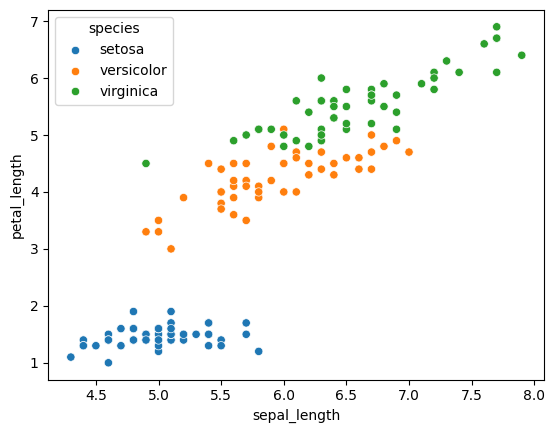

In [116]:
sns.scatterplot(x='sepal_length', y='petal_length', hue='species', data=df_iris)
plt.show()


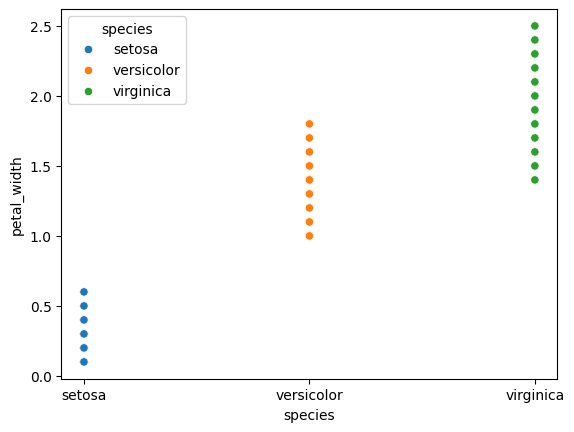

In [117]:
sns.scatterplot(x='species', y='petal_width', hue='species', data=df_iris)
plt.show()


# Problem #4 Perform EDA with Pandas Profiler.

In [118]:
from ydata_profiling import ProfileReport

profile = ProfileReport(data, title="Titanic Profiling Report", explorative=True)
profile.to_file("titanic_eda_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 73584.28it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]